# Statistical Analysis of Hospital Readmission

This notebook applies statistical hypothesis testing techniques to investigate relationships between clinical variables and hospital readmission outcomes.

The objective is to determine whether observed patterns are statistically significant and potentially meaningful in a healthcare context.

## Importing Libraries and Dataset

In [1]:
import pandas as pd

from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_csv(
    "/drive/hospital-readmission-project/data/cleaned_hospital_data.csv"
)

## Mann-Whitney U Test

This test evaluates whether hospital stay duration differs significantly between patients who were readmitted within 30 days and those who were not.

Because hospital stay data may not follow a normal distribution, a non-parametric test was selected.

In [3]:
df["readmitted_binary"] = (
    df["readmitted"] == "<30"
)

In [9]:
group1 = df[
    df["readmitted_binary"]
]["time_in_hospital"]

group2 = df[
    ~df["readmitted_binary"]
]["time_in_hospital"]

stat, p = mannwhitneyu(
    group1,
    group2
)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 560893881.0
P-value: 2.689648414149974e-59


### Interpretation

The Mann-Whitney U test produced a statistically significant result (p < 0.05), suggesting that hospital stay duration differs between readmitted and non-readmitted patients.

This may indicate that longer hospitalization is associated with increased readmission risk and greater clinical complexity.

## Chi-Square Test of Independence

This analysis examines whether insulin treatment status is associated with patient readmission outcomes.

In [10]:
contingency_table = pd.crosstab(
    df["insulin"],
    df["readmitted_binary"]
)

chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 190.8588139978854
P-value: 3.981889070324298e-41


### Interpretation

The Chi-Square test identified a statistically significant association between insulin treatment patterns and hospital readmission outcomes.

This suggests that treatment-related variables may contribute to understanding patient risk profiles and healthcare utilization patterns.

In [11]:
%pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt

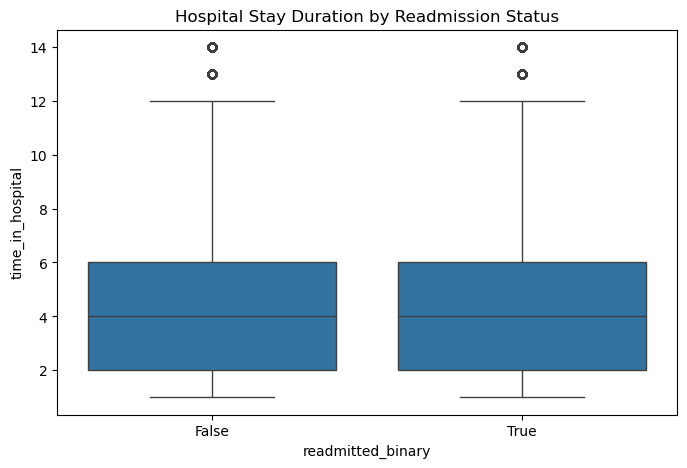

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="readmitted_binary",
    y="time_in_hospital"
)

plt.title("Hospital Stay Duration by Readmission Status")

plt.show()

### Insight

Patients who experienced early readmission appear to have longer hospital stays on average, supporting the statistical findings from the Mann-Whitney U test.

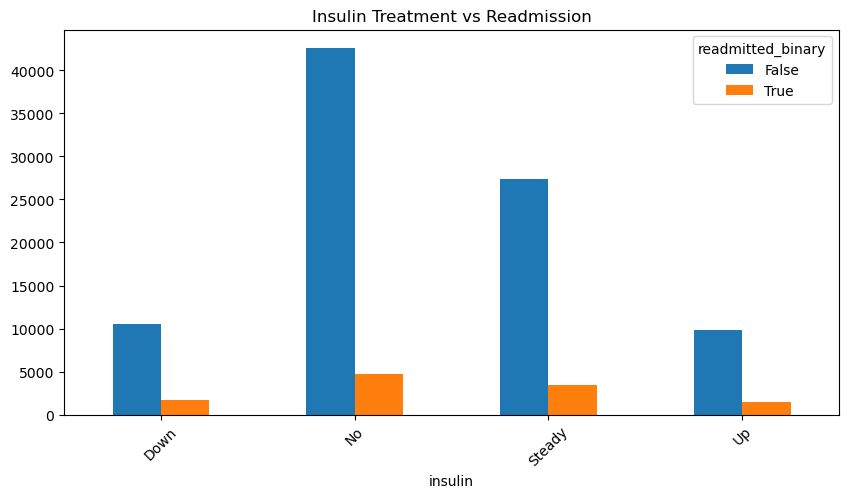

In [13]:
contingency_table.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Insulin Treatment vs Readmission")

plt.xticks(rotation=45)

plt.show()

### Insight

Differences in insulin treatment categories appear across readmission groups, visually reinforcing the statistically significant association identified in the Chi-Square analysis.

### Hypothesis

H0: There is no difference in hospital stay duration between readmitted and non-readmitted patients.

H1: There is a significant difference in hospital stay duration between the two groups.

# Statistical Analysis Conclusion

The statistical analyses identified significant relationships between hospitalization patterns, insulin treatment status, and patient readmission outcomes.

These findings suggest that both clinical complexity and treatment-related variables may contribute to hospital readmission risk.

The results from this notebook can support future predictive modeling and healthcare decision-making workflows.